Based on https://github.com/XENON1T/CEvNS/blob/master/notebooks/B8_neutrino_spectrum.ipynb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json as js
from tqdm import tqdm

In [3]:
params = {
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
    'font.family' : 'serif',
    'font.size' : 15,
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    'xtick.major.size' : 8,
    'ytick.major.size' : 8,
    'xtick.major.width' : 1.5,
    'ytick.major.width' : 1.5,
    'axes.linewidth' : 1.5,
    'axes.labelsize' : 17
}

plt.rcParams.update(params)
# plt.rc('text', usetex=True)

In [4]:
""" IN SI UNIT """
""" Reduced Planck Constant in J·s """
HBAR = 1.054571800E-34
""" Speed of Light in m/s """
C = 2.99792458E8
""" Avogaro's Number in 1/mol """
A_V = 6.022140857E23
""" Charge of Electron in C """
CH_E = 1.6021766208E-19

""" keV in J """
KEV = 1e3 * CH_E
""" GeV in J """
GEV = 1e9 * CH_E

In [5]:
Xe124 = {
    'Type'		: 'Xe124',
    'MassNum'	: 124,
    'AtomicNum'	: 54,
    'Mass'		: 123.905893,
    'Spin'		: 0,
    'Fraction'	: 9.52E-4
}

Xe126 = {
    'Type'		: 'Xe126',
    'MassNum'	: 126,
    'AtomicNum'	: 54,
    'Mass'		: 125.904274,
    'Spin'		: 0,
    'Fraction'	: 8.90E-4
}

Xe128 = {
    'Type'		: 'Xe128',
    'MassNum'	: 128,
    'AtomicNum'	: 54,
    'Mass'		: 127.9035313,
    'Spin'		: 0,
    'Fraction'	: 0.019102
}

Xe129 = {
    'Type'		: 'Xe129',
    'MassNum'	: 129,
    'AtomicNum'	: 54,
    'Mass'		: 128.9047794,
    'Spin'		: 0.5,
    'Fraction'	: 0.264006
}

Xe130 = {
    'Type'		: 'Xe130',
    'MassNum'	: 130,
    'AtomicNum'	: 54,
    'Mass'		: 129.9035080,
    'Spin'		: 0,
    'Fraction'	: 0.040710
}

Xe131 = {
    'Type'		: 'Xe131',
    'MassNum'	: 131,
    'AtomicNum'	: 54,
    'Mass'		: 130.9050824,
    'Spin'		: 1.5,
    'Fraction'	: 0.212324
}

Xe132 = {
    'Type'		: 'Xe132',
    'MassNum'	: 132,
    'AtomicNum'	: 54,
    'Mass'		: 131.9041535,
    'Spin'		: 0,
    'Fraction'	: 0.269086
}

Xe134 = {
    'Type'		: 'Xe134',
    'MassNum'	: 134,
    'AtomicNum'	: 54,
    'Mass'		: 133.9053945,
    'Spin'		: 0,
    'Fraction'	: 0.104357
}

Xe136 = {
    'Type'		: 'Xe136',
    'MassNum'	: 136,
    'AtomicNum'	: 54,
    'Mass'		: 135.907219,
    'Spin'		: 0,
    'Fraction'	: 0.088573
}

ATOM_TABLE = {
    'Xe124'	: Xe124,
    'Xe126'	: Xe126,
    'Xe128'	: Xe128,
    'Xe129'	: Xe129,
    'Xe130'	: Xe130,
    'Xe131'	: Xe131,
    'Xe132'	: Xe132,
    'Xe134'	: Xe134,
    'Xe136'	: Xe136
}

In [6]:
GeV = 1.0
MeV = GeV / 1e3
keV = GeV / 1e6
eV = GeV / 1e9

# GeV ^ -1
m = 1.0 / (HBAR * C / GEV) / GeV
cm = m / 1e2
km = m * 1e3
mm = m / 1e3
um = m / 1e6
nm = m / 1e9
pm = m / 1e12
fm = m / 1e15

# GeV
kg = 1.0 * C**2 / GEV * GeV
ton = kg * 1e3
g = kg * 1e-3

# GeV ^ -1
sec = 1.0 * C * m
dy = 24.0 * 3600.0 * sec
yr = 365.0 * dy

# Fermi's const
Gf = 1.1663787e-5 / GeV**2

# Neutron mass
mn = 0.9314940954 * GeV

# Mixing angle
sin2the = 0.2223

# Standard model CEvNS spectrum

In [7]:
from scipy.special import spherical_jn
from scipy.integrate import quad

class TARGET(object):
    def __init__(self, atom, pure = False):
        super(TARGET, self).__init__()
        self.target = atom
        self.spin = atom["Spin"]
        self.abund = 1 if pure else atom["Fraction"]
        self.A = atom["MassNum"]
        self.Z = atom["AtomicNum"]
        self.N = self.A - self.Z
        self.mass = atom["Mass"] * mn
        self.Qw = self.N - (1 - 4.0 * sin2the) * self.Z
    
    def TransMoment(self, Er):
        return np.sqrt(2 * self.mass * Er)
    
    def MinNeutrinoEnergy(self, Er):
        return (Er + np.sqrt(Er**2 + 2 * self.mass * Er)) / 2.0
    
    def MaxRecoilEnergy(self, Ev):
        return 2 * Ev**2 / (self.mass + 2 * Ev)
    
    def FormFactor(self, q):
        if q == 0:
            return 1.0
        a = 0.52 * fm
        c = (1.23 * self.A**(1.0/3.0) - 0.6) * fm
        s = 0.9 * fm
        rn = np.sqrt(c**2 + 7.0 / 3.0 * np.pi**2 * a**2 - 5 * s**2)
        qrn = q * rn
        return (3 * spherical_jn(1, qrn) / qrn)**2 * np.exp(- (q * s)**2)

    #cross-section as given in equation 2 page 9 of CEvNS paper
    def dXsecdErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            return 0
        q = self.TransMoment(Er)
        return Gf**2 / 4.0 / np.pi * self.Qw**2 * self.mass * (1 - self.mass * Er / 2 / Ev**2) * self.FormFactor(q)
    
    def Integrator(self, func, xmin, xmax):
        result, foo = quad(func, xmin, xmax)
        return result
    
    #modified by Riya
    #Assuming mono-energetic neutrinos
    #it is returning events/(ton*keV*Fluence) where fluence is flux integrated over time and so units of cm^(-2)
    def dRatedErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            #print(".")
            return 0
        # f(_ev)=F*delta(_ev), so no-integration
        return self.dXsecdErecoil(Er, Ev) * self.abund / self.mass * (cm**(-2))

In [8]:
NaturalXe = [TARGET(ATOM_TABLE["Xe124"], pure = False),
          TARGET(ATOM_TABLE["Xe126"], pure = False),
          TARGET(ATOM_TABLE["Xe128"], pure = False),
          TARGET(ATOM_TABLE["Xe129"], pure = False),
          TARGET(ATOM_TABLE["Xe130"], pure = False),
          TARGET(ATOM_TABLE["Xe131"], pure = False),
          TARGET(ATOM_TABLE["Xe132"], pure = False),
          TARGET(ATOM_TABLE["Xe134"], pure = False),
          TARGET(ATOM_TABLE["Xe136"], pure = False)]

#  Acceptance for 2-fold

In [9]:
from scipy.interpolate import interp1d

acc_data = pd.read_csv('NR_acceptance_NSI_UL_200811.csv').drop(columns='Unnamed: 0')

accept = acc_data['acceptance']
energy = acc_data['energy'] * keV
accept = interp1d(energy, accept, bounds_error=False, fill_value=0, kind='linear')

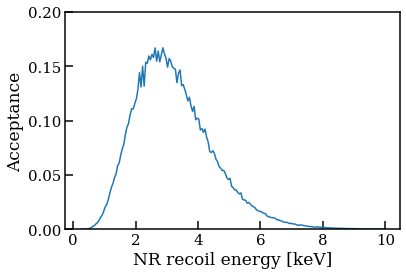

In [10]:
plt.plot(energy / keV, accept(energy))
#plt.xlim(0, 10)
plt.ylim(0, 0.2)
plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.show()

In [11]:
er = energy
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])

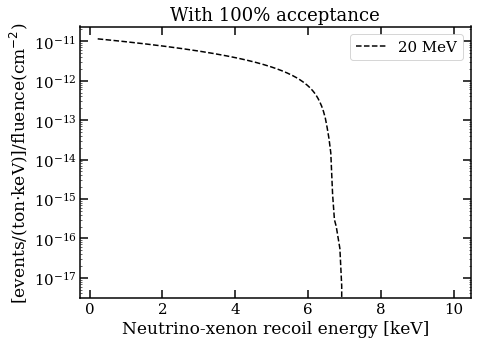

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), 'k--', label="20 MeV")

ax.legend()
ax.set_title("With 100% acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [13]:
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept(x) for x in er])

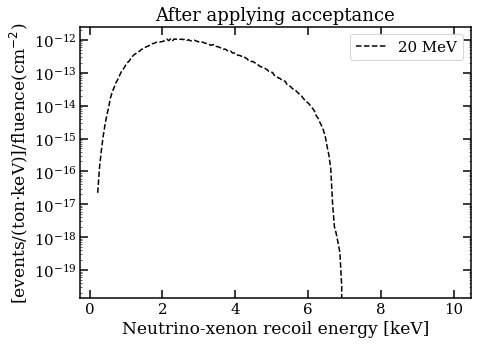

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), 'k--', label="20 MeV")

ax.legend()
ax.set_title(r"After applying acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

# Set constraints

In [80]:
np.linspace(15, 100, 18)

array([ 15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,
        70.,  75.,  80.,  85.,  90.,  95., 100.])

In [15]:
Neutrino_Energy = np.linspace(15, 100, 18)
er = energy
delta_energy = (er[1] - er[0])
total_rate = []
for Ev in Neutrino_Energy:
    tot_rate = np.array([sum([xe.dRatedErecoil(x, Ev*MeV) for xe in NaturalXe]) * accept(x) for x in er])
    total_rate.append(np.sum(tot_rate) * delta_energy * 1.04 * ton)

total_rate_np = np.array(total_rate)

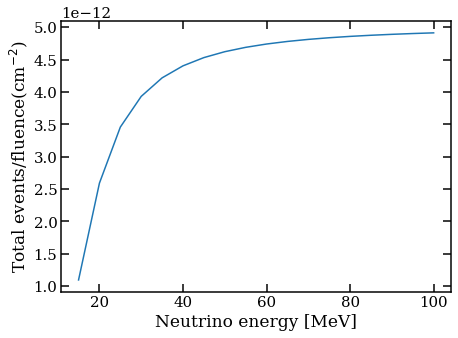

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy, total_rate_np)

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

Events coincident with a GW can be assumed to follow a Poisson distribution. Let p be the probability of not observing an event for a GW.

Then, p^4 is the probability of not observing an event for 4 GWs. To set an upper limit at 90% confidence, we say that what we observe had only 10% probability, i.e. p^4 = (0.1)

p = (0.1)^(1/4) = 0.56234

So, we need to find the expectation value (\mu) for which cdf of 0 is 0.56234

In [161]:
(0.1)**(1/4)

0.5623413251903491

In [17]:
from scipy.stats import poisson

In [18]:
poisson.cdf(0, mu=0.575)

0.5627048688069557

In [19]:
upper_lim_fluence_2_fold = 0.575/total_rate_np

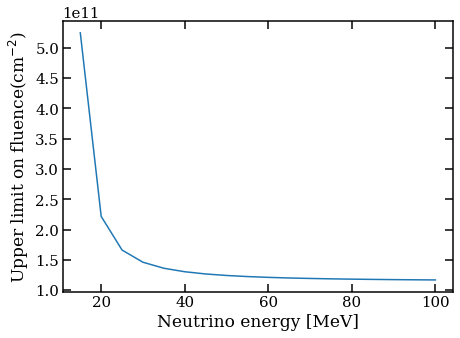

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy, upper_lim_fluence_2_fold)

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

#  Acceptance for 3-fold

https://github.com/XENON1T/SR1Results/tree/master/Calibration/TemplateFiles/180420/run_combined_source_combined/acceptances

In [21]:
import pickle

In [22]:
acceptanceFileNames = [
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr0', # SR0 WIMPs
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr1'  # SR1 WIMPs
]
percentiles = [pickle.load(open(af + '.pkl', 'rb')) for af in acceptanceFileNames]

In [23]:
percentiles[0]['energy_edges'].all() == percentiles[1]['energy_edges'].all()

True

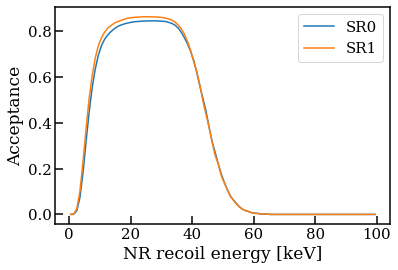

In [94]:
for i in (0, 1):
    energyEdges = percentiles[i]['energy_edges']* keV
    energyCenters = (energyEdges[1:] + energyEdges[:-1]) / 2.
    accept = percentiles[i]['energy']['totalcombacc'].T[1]
    plt.plot(energyCenters/keV, accept, label = 'SR'+str(i))
plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.legend()
plt.show()

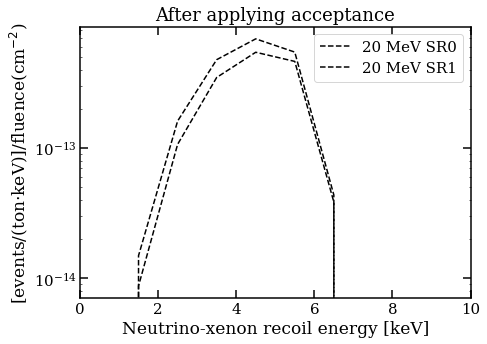

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

for j in (0, 1):
    accept = percentiles[j]['energy']['totalcombacc'].T[1]
    tot_rate = []
    for i in range(0,np.shape(energyCenters)[0]):
        tot_rate.append(sum([xe.dRatedErecoil(energyCenters[i], 20*MeV) for xe in NaturalXe]) * accept[i])

    ax.semilogy(energyCenters/keV, np.array(tot_rate) / (keV**(-1) * ton**(-1)), 'k--', label="20 MeV SR"+str(j))

ax.legend()
ax.set_title(r"After applying acceptance")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [96]:
np.linspace(30, 100, 15)

array([ 30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,
        85.,  90.,  95., 100.])

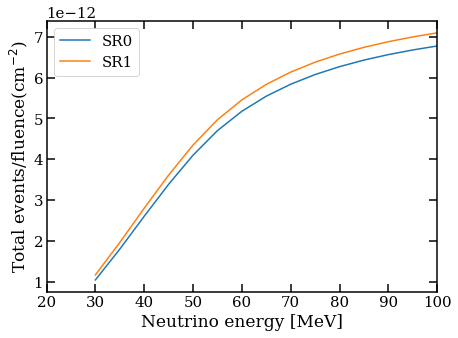

In [100]:
Neutrino_Energy = np.linspace(30, 100, 15)
delta_energy = (er[1] - er[0])

fig, ax = plt.subplots(1, 1, figsize=(7,5))

for j in (0, 1):
    accept = percentiles[j]['energy']['totalcombacc'].T[1]
    total_rate = []
    for Ev in Neutrino_Energy:
        tot_rate = []
        for i in range(0,np.shape(energyCenters)[0]):
            tot_rate.append(sum([xe.dRatedErecoil(energyCenters[i], Ev*MeV) for xe in NaturalXe]) * accept[i])
        total_rate.append(np.sum(tot_rate) * delta_energy * 1.3 * ton)
    total_rate_np = np.array(total_rate)
    plt.plot(Neutrino_Energy, total_rate_np, label = 'SR'+str(j))
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.xlim(20,100)
ax.legend()

plt.show()

Events coincident with a GW can be assumed to follow a Poisson distribution. Let p1 (p0) be the probability of not observing an event for a GW in SR1 (SR0).

Then, p1^4 x p0 is the probability of not observing an event for 5 GWs. To set an upper limit at 90% confidence, we say that what we observe had only 10% probability, i.e. p1^4 x p0 = (0.1)

Since p1 ~ p0

p = (0.1)^(1/5) = 0.631

So, we need to find the expectation value (\mu) for which cdf of 0 is 0.631


In [254]:
0.1**(1/5)

0.6309573444801932

In [27]:
poisson.cdf(0, mu=0.46)

0.6312836455069257

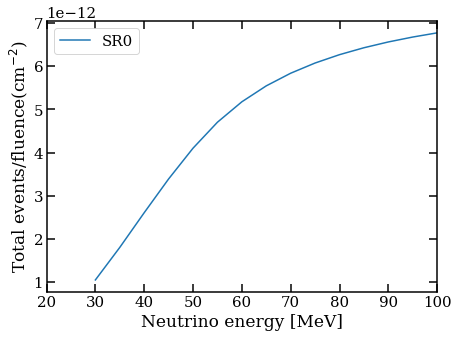

In [101]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

accept = percentiles[0]['energy']['totalcombacc'].T[1]
total_rate = []
for Ev in Neutrino_Energy:
    tot_rate = []
    for i in range(0,np.shape(energyCenters)[0]):
        tot_rate.append(sum([xe.dRatedErecoil(energyCenters[i], Ev*MeV) for xe in NaturalXe]) * accept[i])
    total_rate.append(np.sum(tot_rate) * delta_energy * 1.3 * ton)
total_rate_np = np.array(total_rate)
plt.plot(Neutrino_Energy, total_rate_np, label = 'SR0')
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.xlim(20,100)
ax.legend()

plt.show()

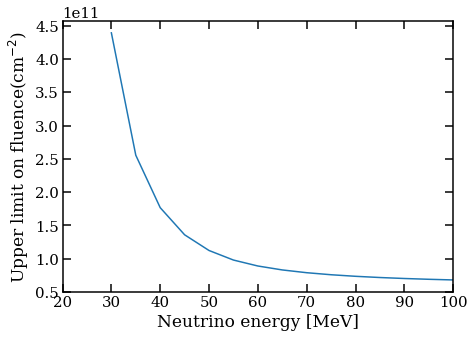

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
upper_lim_fluence_3_fold = 0.46/total_rate_np
plt.plot(Neutrino_Energy, upper_lim_fluence_3_fold)

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.xlim(20,100)

plt.show()

#  Acceptance for S2-only

s2only_efficiency.csv is created using https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb

where 'Energy' = d['es'] & 'Efficiency' = d['efficiency_nounc']

This efficiency includes reduction in fiducial target mass from 2.004 tonne.

In [104]:
acc_data = pd.read_csv('s2only_efficiency.csv')
accept = acc_data['Efficiency']*0.7 #because 30% of data is used for training
energy = acc_data['Energy'] * keV

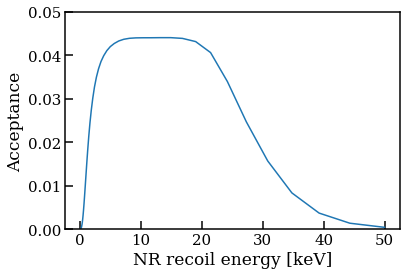

In [105]:
plt.plot(energy / keV, accept)
#plt.xlim(0, 10)
plt.ylim(0, 0.05)
plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.show()

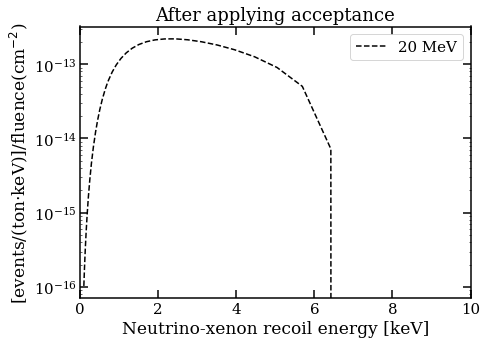

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

tot_rate = []
for i in range(0,np.shape(energy)[0]):
        tot_rate.append(sum([xe.dRatedErecoil(energy[i], 20*MeV) for xe in NaturalXe]) * accept[i])

ax.semilogy(energy/keV, np.array(tot_rate) / (keV**(-1) * ton**(-1)), 'k--', label="20 MeV")

ax.legend()
ax.set_title(r"After applying acceptance")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

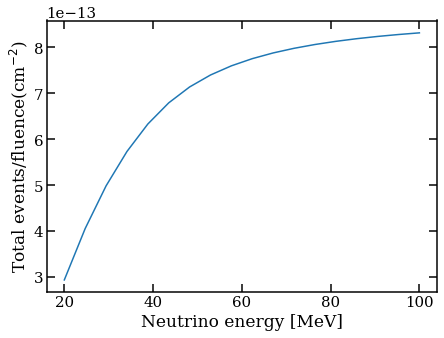

In [107]:
Neutrino_Energy = np.linspace(20, 100, 18)
delta_energy = (er[1] - er[0])

fig, ax = plt.subplots(1, 1, figsize=(7,5))

total_rate = []
for Ev in Neutrino_Energy:
    tot_rate = []
    for i in range(0,np.shape(energy)[0]):
        tot_rate.append(sum([xe.dRatedErecoil(energy[i], Ev*MeV) for xe in NaturalXe]) * accept[i])
    total_rate.append(np.sum(tot_rate) * delta_energy * 2.004 * ton)
total_rate_np = np.array(total_rate)
plt.plot(Neutrino_Energy, total_rate_np)
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#plt.xlim(20,100)
#ax.legend()

plt.show()

Using the same logic as in 2-fold coincidence, we need to find the expectation value (\mu) for which cdf of 0 is 0.56234

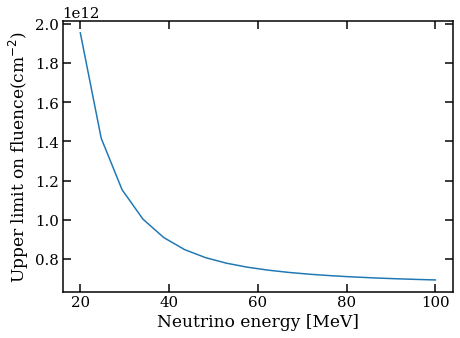

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
upper_lim_fluence_s2only = 0.575/total_rate_np
plt.plot(Neutrino_Energy, upper_lim_fluence_s2only)

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#plt.xlim(20,100)

plt.show()

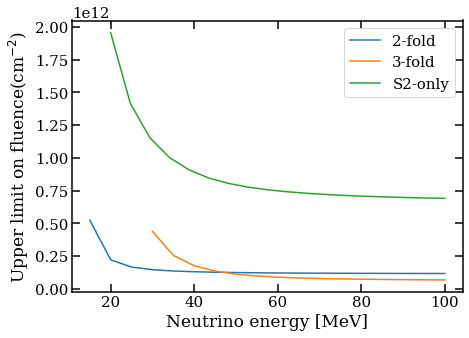

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(np.linspace(15, 100, 18), upper_lim_fluence_2_fold, label="2-fold")
plt.plot(np.linspace(30, 100, 15), upper_lim_fluence_3_fold, label="3-fold")
plt.plot(Neutrino_Energy, upper_lim_fluence_s2only, label="S2-only")

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
#plt.xlim(20,100)
plt.legend()
plt.show()